In [1]:
import os
import splitfolders
import tensorflow as tf
import albumentations as A
import matplotlib.pyplot as plt 
from tensorflow.keras import layers,models
from tensorflow.keras.utils import image_dataset_from_directory
from tensorflow.keras.callbacks import EarlyStopping


In [2]:
classes = os.listdir("C:\\Users\\Abdulla\\OneDrive - Faculty of Computers and Information\\Desktop\\archive\\Dataset about Egyptian statues\\dataset")
num_classes = len(classes)

dataset = "C:\\Users\\Abdulla\\OneDrive - Faculty of Computers and Information\\Desktop\\archive\\Dataset about Egyptian statues\\dataset"
splitfolders.ratio(dataset,output='dataset',seed=1337,ratio=(.7,.2,.1))

sample = tf.keras.utils.image_dataset_from_directory("dataset/train",image_size=(256,256),batch_size=32)

train_ds = image_dataset_from_directory("dataset/train",image_size=(256,256),batch_size=None)
val_ds = image_dataset_from_directory("dataset/val",image_size=(256,256),batch_size=None)
test_ds = image_dataset_from_directory("dataset/test",image_size=(256,256),batch_size=None)

Copying files: 3504 files [00:13, 252.01 files/s]


Found 2420 files belonging to 32 classes.
Found 2420 files belonging to 32 classes.
Found 685 files belonging to 32 classes.
Found 379 files belonging to 32 classes.


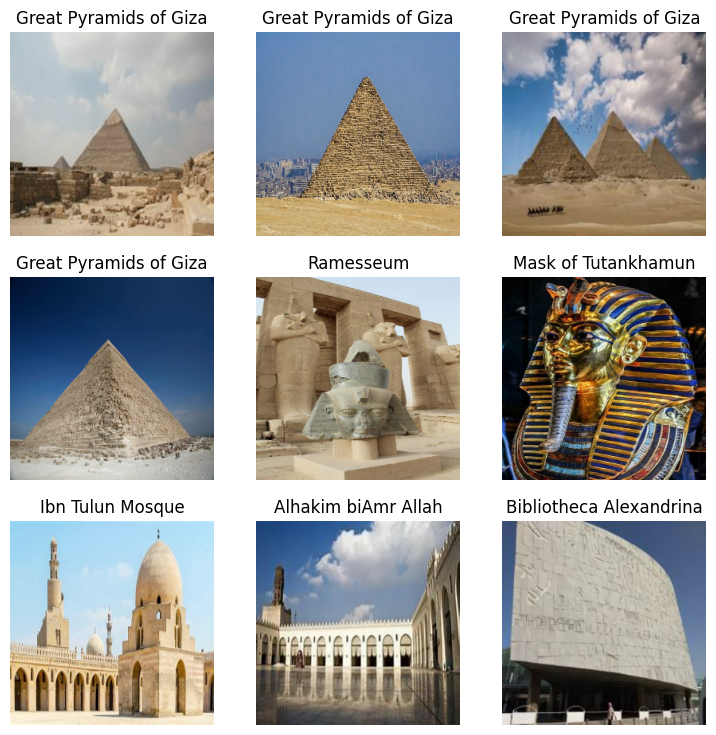

In [4]:
plt.figure(figsize=(9,9))

for images, labels in sample.take(1):
    for i in range(9):
        ax = plt.subplot(3,3,i+1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(classes[int(labels[i])])
        plt.axis("off")
        
    
plt.show()

In [ ]:
train_transform = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.1),
    A.RandomBrightnessContrast(p=0.2),
    A.Rotate(limit=15, p=0.5),
    A.RandomResizedCrop(size=(256,256), scale=(0.8, 1.0), p=0.5),
    A.Blur(p=0.2),
    A.GaussNoise(var_limit=(10.0, 50.0),p=0.2),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    A.HueSaturationValue(p=0.2)
])

val_transform = A.Compose([
    A.Resize(height=256, width=256),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225))
])

In [ ]:
def apply_tranform(image,label,transform):
    def apply_augmentation(image):
        if len(image.shape) == 4:
            image = image[0]
            
        augmented = transform(image=image)
        return augmented['image']
    
    augmented_image = tf.numpy_function(apply_augmentation,[image],tf.float32)
    
    augmented_image.set_shape((256,256,3))
    return augmented_image,label

main_train_ds = train_ds.map(lambda image,label:apply_tranform(image, label, train_transform)).batch(32).shuffle(1000).prefetch(tf.data.AUTOTUNE)
main_val_ds = val_ds.map(lambda image,label:apply_tranform(image, label, val_transform)).batch(32).shuffle(1000).prefetch(tf.data.AUTOTUNE)
main_test_ds = test_ds.map(lambda image,label:apply_tranform(image, label, val_transform)).batch(32).shuffle(1000).prefetch(tf.data.AUTOTUNE)

In [ ]:
cnn = models.Sequential([
    layers.Conv2D(32,(3,3), activation='relu', input_shape=(256,256,3)),
    layers.MaxPooling2D((2,2)),
    
    layers.Conv2D(64,(3,3), activation='relu' ),
    layers.MaxPooling2D((2,2)),
    
    layers.Conv2D(128,(3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    
    layers.Conv2D(256,(3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    
    layers.Flatten(),
    
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    
    layers.Dense(num_classes, activation='softmax')
])

cnn.compile(optimizer='adam',
            loss='sparse_categorical_crossentropy',
            metrics=['accuracy'])

cnn.summary()

In [ ]:
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

cnn.fit(main_train_ds,
        validation_data=main_val_ds,
        epochs=20,
        callbacks=[early_stopping])